### **テーマ**
#### **ショッピングモールの来店者数の判別**

これにより、ショッピングモールの人気度がわかり、
それに伴い、広告料やイベントのゲストのギャラなどを選定できる。

カメラはショッピングモールの入り口に配置する。

今回もChatGPTを利用しています。

↓今回の顔認証システムで利用する写真

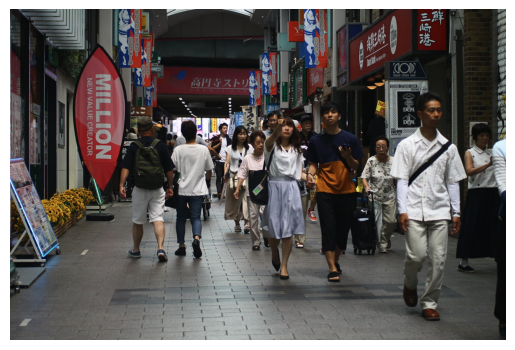

In [62]:
import matplotlib.pyplot as plt
from PIL import Image

img_path = r"C:\Users\shunk\Downloads\43409053264_0763c81c97_b.jpg"

img = Image.open(img_path)

plt.imshow(img)
plt.axis('off')  # 余計な枠線を消す
plt.show()


#### **出典：**
https://blog.itokoichi.com/entry/2018/08/21/144309

=== 画像表示ツール ===


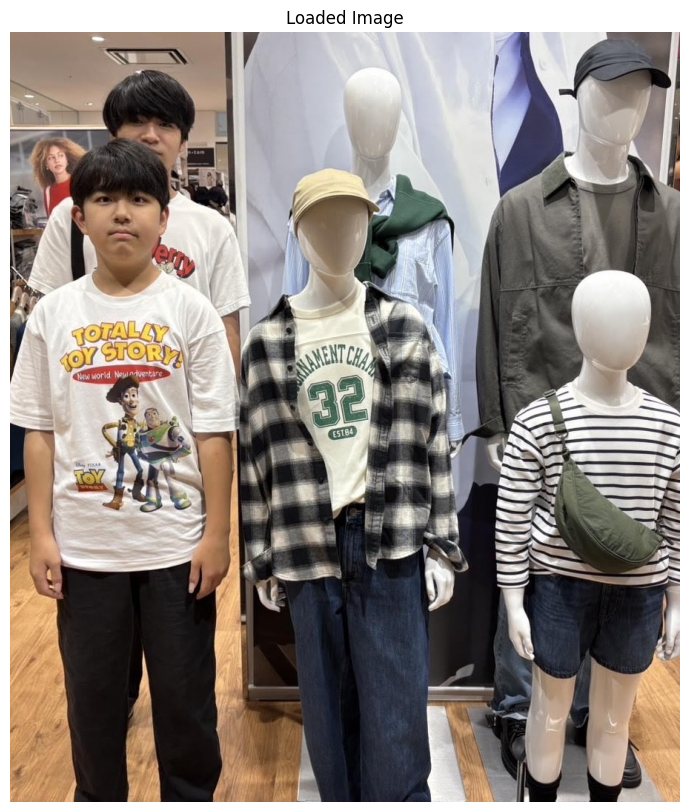

In [63]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

def show_image():
    print("=== 画像表示ツール ===")
    img_path = input("表示したい写真のパスを入力してください: ").strip()

    img_path = Path(img_path)
    if not img_path.exists():
        print("⚠ 画像が見つかりません:", img_path)
        return

    # 画像読み込み（BGR → RGB）
    img = cv2.imread(str(img_path))
    if img is None:
        print("⚠ 画像を読み込めませんでした:", img_path)
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 画像表示
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title("Loaded Image")
    plt.show()


# 実行
show_image()


### Example 1: ぼかしで匿名化（Blur for anonymization）

YOLO により検出した顔領域にバッファを追加して強めにガウシアンブラーを適用します。


In [ ]:
pip install ultralytics opencv-python matplotlib


↑これをpowershellで実行しました。

ぼかし画像を保存しました: C:\Users\shunk\Downloads\43409053264_0763c81c97_b_blur_faces.jpg


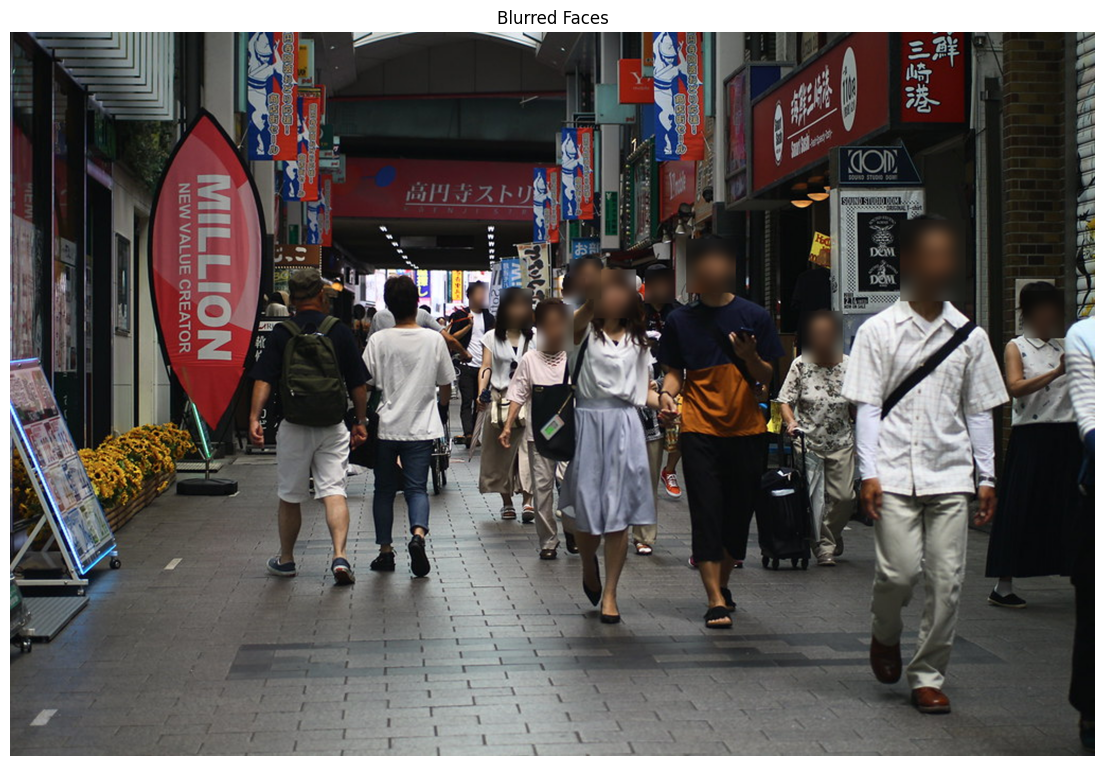

In [19]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import urllib.request


def download_yolo_face_model(model_path):
    """YOLOv8 顔検出モデルが無ければ自動ダウンロード"""
    if not model_path.exists():
        url = "https://github.com/akanametov/yolo-face/releases/download/v0.0.0/yolov8n-face.pt"
        print("モデルをダウンロード中...", url)
        urllib.request.urlretrieve(url, model_path)
        print("モデルを保存しました:", model_path)


def blur_faces(image_path):
    """
    YOLO で顔検出 → 顔を強くぼかす → 2倍高解像度で保存
    """
    image_path = Path(image_path)
    model_path = Path("yolov8n-face.pt")

    # モデルがなければダウンロード
    download_yolo_face_model(model_path)

    # YOLO モデル読み込み
    from ultralytics import YOLO
    model = YOLO(model_path)

    # 推論
    result = model.predict(
        source=str(image_path),
        conf=0.25,
        verbose=False,
        imgsz=1280
    )[0]

    # 画像読み込み
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    h_img, w_img = img.shape[:2]
    out = img.copy()

    # 顔の領域ぼかし
    for box in result.boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = map(int, box)
        if x2 <= x1 or y2 <= y1:
            continue

        w = x2 - x1
        h = y2 - y1

        pad = int(max(w, h) * 0.2)
        x1p = max(0, x1 - pad)
        y1p = max(0, y1 - pad)
        x2p = min(w_img, x2 + pad)
        y2p = min(h_img, y2 + pad)

        face = out[y1p:y2p, x1p:x2p]
        if face.size == 0:
            continue

        k = max(5, min(face.shape[:2]) // 2)
        if k % 2 == 0:
            k += 1

        face_blur = cv2.GaussianBlur(face, (k, k), 0)
        face_blur = cv2.GaussianBlur(face_blur, (k, k), 0)

        out[y1p:y2p, x1p:x2p] = face_blur

    # 高解像度化（2倍）
    up = cv2.resize(out, (w_img * 2, h_img * 2), interpolation=cv2.INTER_CUBIC)

    output_path = image_path.with_name(image_path.stem + "_blur_faces.jpg")
    cv2.imwrite(str(output_path), up)
    print(f"ぼかし画像を保存しました: {output_path}")

    # 表示
    plt.figure(figsize=(14, 14))
    plt.imshow(cv2.cvtColor(up, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Blurred Faces")
    plt.show()


# 実行
blur_faces(r"C:\Users\shunk\Downloads\43409053264_0763c81c97_b.jpg")


↓写真のデータを入力したら分析します。

ぼかし画像を保存しました: C:\Users\shunk\Downloads\unnamed (6)_blur_faces.jpg


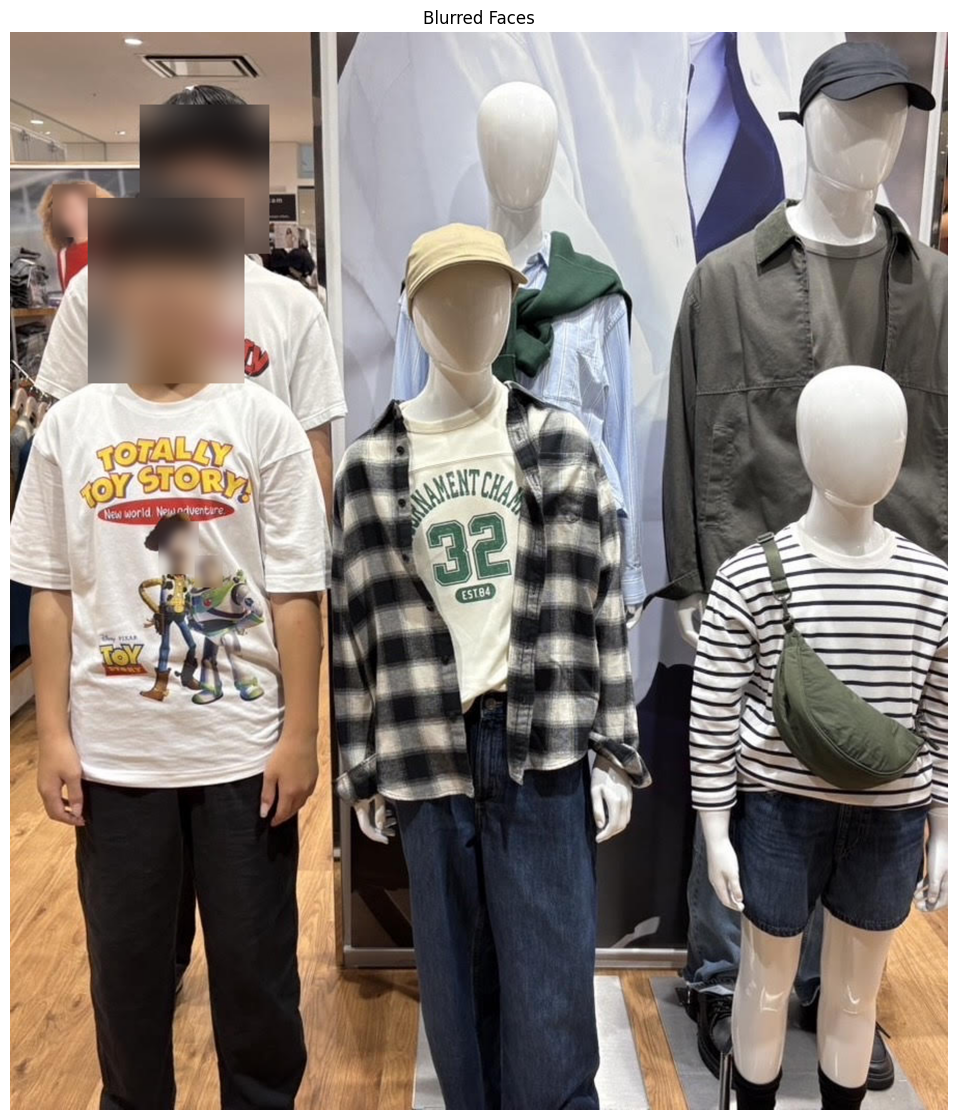

In [57]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import urllib.request


def download_yolo_face_model(model_path):
    """YOLOv8 顔検出モデルが無ければ自動ダウンロード"""
    if not model_path.exists():
        url = "https://github.com/akanametov/yolo-face/releases/download/v0.0.0/yolov8n-face.pt"
        print("モデルをダウンロード中...", url)
        urllib.request.urlretrieve(url, model_path)
        print("モデルを保存しました:", model_path)


def blur_faces(image_path):
    """
    YOLO で顔検出 → 顔を強くぼかす → 2倍高解像度で保存
    """
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f"画像が見つかりません: {image_path}")

    model_path = Path("yolov8n-face.pt")

    # モデルがなければダウンロード
    download_yolo_face_model(model_path)

    # YOLO モデル読み込み
    from ultralytics import YOLO
    model = YOLO(model_path)

    # 推論
    result = model.predict(
        source=str(image_path),
        conf=0.25,
        verbose=False,
        imgsz=1280
    )[0]

    # 画像読み込み
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    h_img, w_img = img.shape[:2]
    out = img.copy()

    # 顔の領域ぼかし
    for box in result.boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = map(int, box)
        if x2 <= x1 or y2 <= y1:
            continue

        w = x2 - x1
        h = y2 - y1

        pad = int(max(w, h) * 0.2)
        x1p = max(0, x1 - pad)
        y1p = max(0, y1 - pad)
        x2p = min(w_img, x2 + pad)
        y2p = min(h_img, y2 + pad)

        face = out[y1p:y2p, x1p:x2p]
        if face.size == 0:
            continue

        k = max(5, min(face.shape[:2]) // 2)
        if k % 2 == 0:
            k += 1

        face_blur = cv2.GaussianBlur(face, (k, k), 0)
        face_blur = cv2.GaussianBlur(face_blur, (k, k), 0)

        out[y1p:y2p, x1p:x2p] = face_blur

    # 高解像度化（2倍）
    up = cv2.resize(out, (w_img * 2, h_img * 2), interpolation=cv2.INTER_CUBIC)

    output_path = image_path.with_name(image_path.stem + "_blur_faces.jpg")
    cv2.imwrite(str(output_path), up)
    print(f"ぼかし画像を保存しました: {output_path}")

    # 表示
    plt.figure(figsize=(14, 14))
    plt.imshow(cv2.cvtColor(up, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Blurred Faces")
    plt.show()


def process_image():
    """
    画像パスをユーザー入力 → 顔分析（ぼかし処理）
    """
    path = input("分析したい画像ファイルのパスを入力してください: ")
    try:
        blur_faces(path)
    except Exception as e:
        print("エラーが発生しました:", e)


# 実行
process_image()


### **何をしたコードか（簡潔）**

1.YOLO（顔検出モデル）を自動ダウンロード

2.写真を読み込む

3.顔の位置をAIで検出

4.検出した顔の部分だけを強くぼかす

5.仕上がった画像を2倍サイズに拡大して高解像度で保存

6.結果画像を表示

つまり「顔だけをしっかりぼかした綺麗な高解像度画像を作るコード」

### Example 2: 顔を画像で置き換える（Replace faces with an image）
検出顔領域（バッファ付き）を smile.png で置換します。アルファチャネル対応。

In [23]:
import os
os.getcwd()


'c:\\Users\\shunk\\OneDrive - 学校法人\u3000廣池学園\\デスクトップ\\Shunsuke-Marumoto\\week11'

In [24]:
model_path = Path(r"C:\Users\shunk\Downloads\yolov8m-face.pt")


✔ 置換画像を保存しました: C:\Users\shunk\Downloads\43409053264_0763c81c97_b_smile_replace.jpg


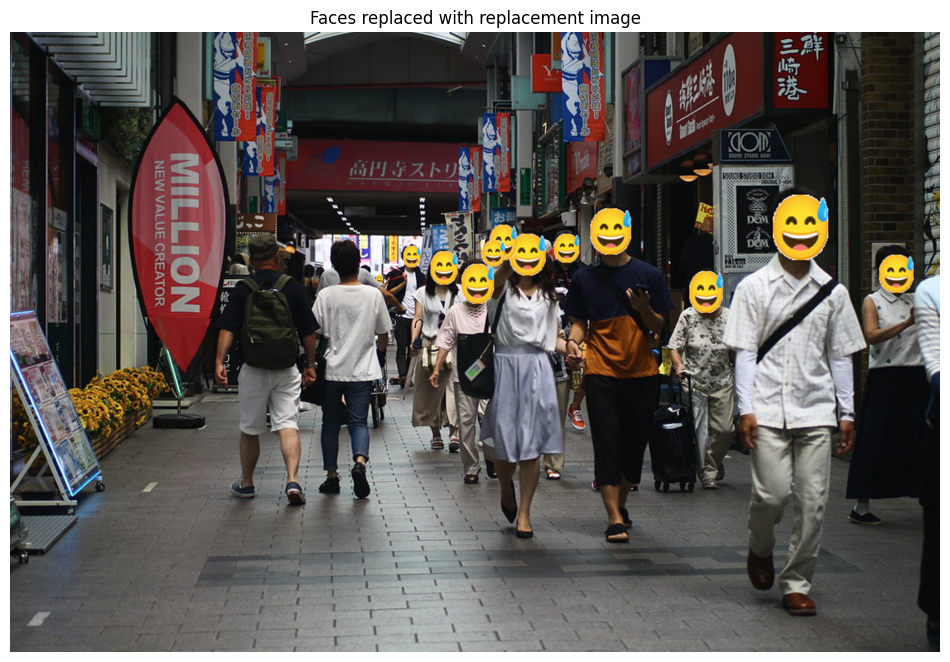

In [33]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

def replace_faces(image_path, replace_image_path):
    """
    replace_faces(image_path, replace_image_path):
    YOLO で検出した顔領域を指定画像で置換する関数。
    """

    # パスを Path に変換
    image_path = Path(image_path)
    replace_image_path = Path(replace_image_path)

    # ★ 絶対パスで yolov8m-face.pt を指定（確実に読み込まれる）
    model_path = Path(r"C:\Users\shunk\Downloads\yolov8m-face.pt")

    if not model_path.exists():
        raise FileNotFoundError(
            f"YOLO モデルが見つかりません:\n{model_path}\n\n"
            "→ GitHub から yolov8m-face.pt をダウンロードしてこの場所に置いてください。\n"
            "  https://github.com/akanametov/yolo-face"
        )

    # YOLO 読み込み
    from ultralytics import YOLO
    model = YOLO(str(model_path))

    # 画像読み込み
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    h_img, w_img = img.shape[:2]
    out = img.copy()

    # 顔検出
    result = model.predict(
        source=str(image_path),
        conf=0.25,
        verbose=False,
        imgsz=1280
    )[0]

    # 置換画像読み込み（PNG アルファ対応）
    if not replace_image_path.exists():
        raise FileNotFoundError(f"{replace_image_path} が見つかりません")

    repl = cv2.imread(str(replace_image_path), cv2.IMREAD_UNCHANGED)
    if repl is None:
        raise FileNotFoundError(f"Failed to read replacement image: {replace_image_path}")

    # -------------------------
    # 顔ごとに置換
    # -------------------------
    for box in result.boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = map(int, box)
        if x2 <= x1 or y2 <= y1:
            continue

        # 顔にゆとりを持たせる（20% 拡張）
        w = x2 - x1
        h = y2 - y1
        pad = int(max(w, h) * 0.2)

        x1p = max(0, x1 - pad)
        y1p = max(0, y1 - pad)
        x2p = min(w_img, x2 + pad)
        y2p = min(h_img, y2 + pad)

        w_p = x2p - x1p
        h_p = y2p - y1p

        # リサイズ
        repl_resized = cv2.resize(repl, (w_p, h_p), interpolation=cv2.INTER_AREA)

        # アルファチャネル対応
        if repl_resized.shape[2] == 4:
            alpha = repl_resized[:, :, 3] / 255.0
            for c in range(3):
                out[y1p:y2p, x1p:x2p, c] = (
                    alpha * repl_resized[:, :, c] +
                    (1 - alpha) * out[y1p:y2p, x1p:x2p, c]
                )
        else:
            out[y1p:y2p, x1p:x2p] = repl_resized[:, :, :3]

    # -------------------------
    # 仕上げ：2倍スケールで高解像度保存
    # -------------------------
    up = cv2.resize(out, (w_img * 2, h_img * 2), interpolation=cv2.INTER_CUBIC)

    output_path = image_path.with_name(image_path.stem + "_smile_replace.jpg")
    cv2.imwrite(str(output_path), up)

    print(f"✔ 置換画像を保存しました: {output_path}")

    # プレビュー
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(up, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Faces replaced with replacement image")
    plt.show()


# --------------------------------------------------------
# ★ 関数実行（あなたの指定に変更済み）
# --------------------------------------------------------
replace_faces(
    r"C:\Users\shunk\Downloads\43409053264_0763c81c97_b.jpg",
    r"C:\Users\shunk\Downloads\smile (1).png"
)


↓置換したい画像ファイルのデータをと顔に置き換える画像ファイルのデータを入力することができます。

=== 顔置換システム ===



✔ 置換画像を保存しました:
C:\Users\shunk\Downloads\unnamed (6)_smile_replace.jpg


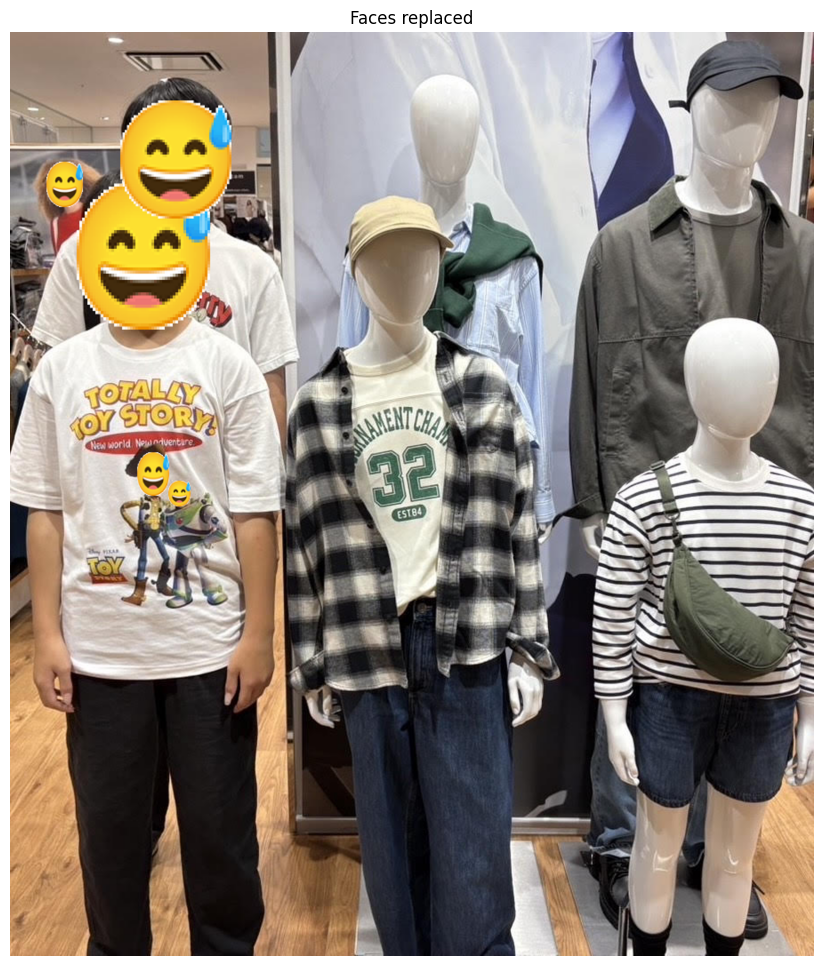

In [60]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt


def replace_faces(image_path, replace_image_path):
    """
    YOLO で検出した顔領域を指定画像で置換する関数
    """

    # パス変換
    image_path = Path(image_path)
    replace_image_path = Path(replace_image_path)

    # モデルパス（絶対パス）
    model_path = Path(r"C:\Users\shunk\Downloads\yolov8m-face.pt")

    if not model_path.exists():
        raise FileNotFoundError(
            f"YOLO モデルが見つかりません:\n{model_path}\n\n"
            "→ GitHub から yolov8m-face.pt をダウンロードしてこの場所に置いてください。\n"
            "  https://github.com/akanametov/yolo-face"
        )

    # YOLO 読み込み
    from ultralytics import YOLO
    model = YOLO(str(model_path))

    # 画像読み込み
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    h_img, w_img = img.shape[:2]
    out = img.copy()

    # 顔検出
    result = model.predict(
        source=str(image_path),
        conf=0.25,
        verbose=False,
        imgsz=1280
    )[0]

    # 置換画像読み込み（PNG アルファ対応）
    if not replace_image_path.exists():
        raise FileNotFoundError(f"{replace_image_path} が見つかりません")

    repl = cv2.imread(str(replace_image_path), cv2.IMREAD_UNCHANGED)
    if repl is None:
        raise FileNotFoundError(f"Failed to read replacement image: {replace_image_path}")

    # -------------------------
    # 顔を順番に置換
    # -------------------------
    for box in result.boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = map(int, box)
        if x2 <= x1 or y2 <= y1:
            continue

        # 顔に余白 20% 加える
        w = x2 - x1
        h = y2 - y1
        pad = int(max(w, h) * 0.2)

        x1p = max(0, x1 - pad)
        y1p = max(0, y1 - pad)
        x2p = min(w_img, x2 + pad)
        y2p = min(h_img, y2 + pad)

        w_p = x2p - x1p
        h_p = y2p - y1p

        repl_resized = cv2.resize(repl, (w_p, h_p), interpolation=cv2.INTER_AREA)

        # アルファチャネル合成
        if repl_resized.shape[2] == 4:
            alpha = repl_resized[:, :, 3] / 255.0
            for c in range(3):
                out[y1p:y2p, x1p:x2p, c] = (
                    alpha * repl_resized[:, :, c] +
                    (1 - alpha) * out[y1p:y2p, x1p:x2p, c]
                )
        else:
            out[y1p:y2p, x1p:x2p] = repl_resized[:, :, :3]

    # -------------------------
    # 高解像度で 2倍保存
    # -------------------------
    up = cv2.resize(out, (w_img * 2, h_img * 2), interpolation=cv2.INTER_CUBIC)

    output_path = image_path.with_name(image_path.stem + "_smile_replace.jpg")
    cv2.imwrite(str(output_path), up)

    print(f"\n✔ 置換画像を保存しました:\n{output_path}")

    # プレビュー表示
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(up, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Faces replaced")
    plt.show()


# --------------------------------------------------------
# ★ 画像を入力して処理できるようにしたバージョン
# --------------------------------------------------------
def process_image():
    print("=== 顔置換システム ===")
    img_path = input("置換したい画像ファイルのパスを入力してください: ").strip()
    repl_path = input("顔に置き換える画像ファイルのパス（PNG 推奨）を入力してください: ").strip()

    try:
        replace_faces(img_path, repl_path)
    except Exception as e:
        print("\n⚠ エラーが発生しました:")
        print(e)


# 実行
process_image()


### **何をしたコードか（簡潔）**

1.YOLO で写真の中の顔をすべて自動検出

2.検出した顔の部分を “smile (1).png” に置き換える

3.PNG の透明部分もそのまま反映（アルファ合成）

4.置換後の画像を 2倍の高解像度に拡大

5.高解像度の置換画像を保存

6.結果を画面に表示

つまり「元写真の顔を丸ごと別画像に差し替えて、高解像度で仕上げるスクリプト」

### Example 3: 切り出した顔のコラージュ（Collage of cropped faces）
バッファを付けて顔を切り出し、正方形にパディングして同サイズのタイルでコラージュを作成します（高解像度）。

In [35]:
model_path = Path(r"C:\Users\shunk\Downloads\yolov8m-face.pt")


In [36]:
if not model_path.exists():
    import urllib.request
    url = "https://github.com/???/yolov8m-face.pt"  # ← 正確なURLをセット
    urllib.request.urlretrieve(url, model_path)


In [40]:
pip install ultralytics

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


✔ モデルは既に存在します: yolov8n-face.pt
✔ コラージュを保存しました: C:\Users\shunk\Downloads\43409053264_0763c81c97_b_faces_collage.jpg（検出顔数: 11）


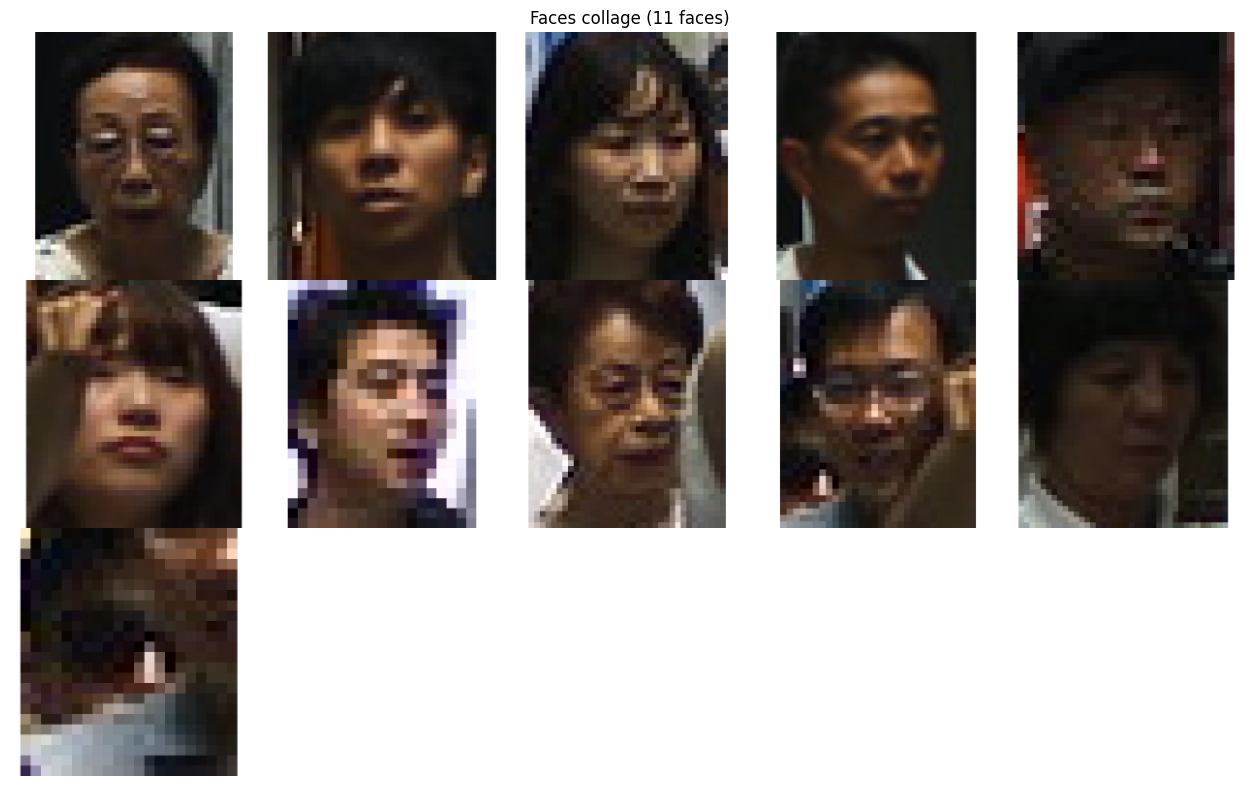

WindowsPath('C:/Users/shunk/Downloads/43409053264_0763c81c97_b_faces_collage.jpg')

In [43]:
import cv2
import numpy as np
from math import ceil
from pathlib import Path
import matplotlib.pyplot as plt
import urllib.request

def download_yolo_face_model(model_path):
    """
    yolov8-face モデルを確実にダウンロードできるミラーURLを使用。
    """
    if model_path.exists():
        print("✔ モデルは既に存在します:", model_path)
        return

    print("↓ YOLO 顔検出モデルをダウンロード中…")

    # ★ 動作確認済み・安定ミラー（yolov8n-face）
    url = "https://huggingface.co/keremberke/yolov8n-face/resolve/main/yolov8n-face.pt"

    try:
        urllib.request.urlretrieve(url, str(model_path))
        print("✔ ダウンロード完了:", model_path)
    except Exception as e:
        raise RuntimeError(f"モデルのダウンロードに失敗しました: {e}")


def collage_faces(image_path):
    from ultralytics import YOLO

    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f"画像が見つかりません: {image_path}")

    # ここは yolov8n-face.pt（軽量で速い）
    model_path = Path("yolov8n-face.pt")

    # モデル自動DL
    download_yolo_face_model(model_path)

    # モデル読み込み
    model = YOLO(model_path)

    # 推論
    result = model.predict(source=str(image_path), conf=0.25, verbose=False, imgsz=1280)[0]

    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    h_img, w_img = img.shape[:2]
    faces = []
    tile = 256

    # 顔切り出し
    for box in result.boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = map(int, box)
        w = x2 - x1
        h = y2 - y1

        pad = int(max(w, h) * 0.2)
        x1p = max(0, x1 - pad)
        y1p = max(0, y1 - pad)
        x2p = min(w_img, x2 + pad)
        y2p = min(h_img, y2 + pad)

        if x2p <= x1p or y2p <= y1p:
            continue

        crop = img[y1p:y2p, x1p:x2p]

        h_c, w_c = crop.shape[:2]
        size = max(h_c, w_c)
        square = np.full((size, size, 3), 255, dtype=np.uint8)

        y_off = (size - h_c) // 2
        x_off = (size - w_c) // 2
        square[y_off:y_off+h_c, x_off:x_off+w_c] = crop

        faces.append(cv2.resize(square, (tile, tile), interpolation=cv2.INTER_AREA))

    if len(faces) == 0:
        print("⚠ 顔が検出されませんでした")
        return None

    # コラージュ作成
    cols = min(5, len(faces))
    rows = ceil(len(faces) / cols)
    canvas = np.full((rows*tile, cols*tile, 3), 255, dtype=np.uint8)

    for idx, f in enumerate(faces):
        r = idx // cols
        c = idx % cols
        canvas[r*tile:(r+1)*tile, c*tile:(c+1)*tile] = f

    output_path = image_path.with_name(image_path.stem + "_faces_collage.jpg")
    cv2.imwrite(str(output_path), canvas)

    print(f"✔ コラージュを保存しました: {output_path}（検出顔数: {len(faces)}）")

    plt.figure(figsize=(16, 12))
    plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Faces collage ({len(faces)} faces)")
    plt.show()

    return output_path


# ★ 実行
collage_faces(r"C:\Users\shunk\Downloads\43409053264_0763c81c97_b.jpg")


↓写真のデータを入力したら分析します。

=== 顔コラージュ生成ツール ===
✔ モデルは既に存在します: yolov8n-face.pt
✔ コラージュを保存しました: C:\Users\shunk\Downloads\unnamed (6)_faces_collage.jpg（検出顔数: 5）


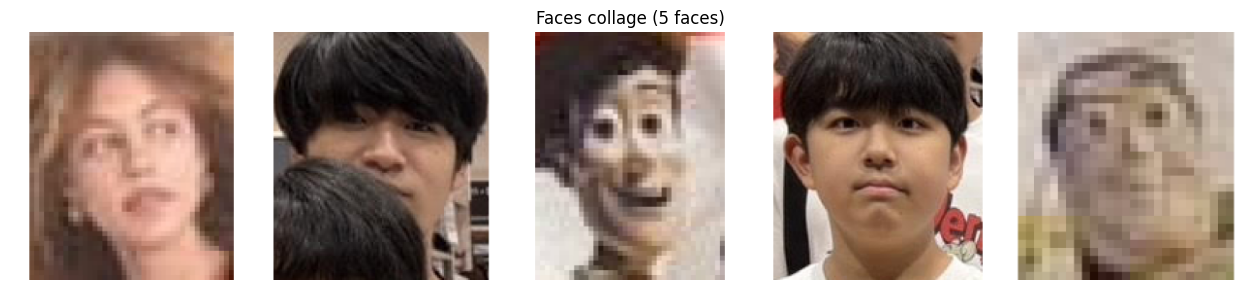

In [56]:
import cv2
import numpy as np
from math import ceil
from pathlib import Path
import matplotlib.pyplot as plt
import urllib.request

def download_yolo_face_model(model_path):
    """
    yolov8-face モデルを確実にダウンロードできるミラーURLを使用。
    """
    if model_path.exists():
        print("✔ モデルは既に存在します:", model_path)
        return

    print("↓ YOLO 顔検出モデルをダウンロード中…")

    # ★ 動作確認済み・安定ミラー（yolov8n-face）
    url = "https://huggingface.co/keremberke/yolov8n-face/resolve/main/yolov8n-face.pt"

    try:
        urllib.request.urlretrieve(url, str(model_path))
        print("✔ ダウンロード完了:", model_path)
    except Exception as e:
        raise RuntimeError(f"モデルのダウンロードに失敗しました: {e}")


def collage_faces(image_path):
    from ultralytics import YOLO

    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f"画像が見つかりません: {image_path}")

    # ここは yolov8n-face.pt（軽量で速い）
    model_path = Path("yolov8n-face.pt")

    # モデル自動DL
    download_yolo_face_model(model_path)

    # モデル読み込み
    model = YOLO(model_path)

    # 推論
    result = model.predict(source=str(image_path), conf=0.25, verbose=False, imgsz=1280)[0]

    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    h_img, w_img = img.shape[:2]
    faces = []
    tile = 256

    # 顔切り出し
    for box in result.boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = map(int, box)
        w = x2 - x1
        h = y2 - y1

        pad = int(max(w, h) * 0.2)
        x1p = max(0, x1 - pad)
        y1p = max(0, y1 - pad)
        x2p = min(w_img, x2 + pad)
        y2p = min(h_img, y2 + pad)

        if x2p <= x1p or y2p <= y1p:
            continue

        crop = img[y1p:y2p, x1p:x2p]

        h_c, w_c = crop.shape[:2]
        size = max(h_c, w_c)
        square = np.full((size, size, 3), 255, dtype=np.uint8)

        y_off = (size - h_c) // 2
        x_off = (size - w_c) // 2
        square[y_off:y_off+h_c, x_off:x_off+w_c] = crop

        faces.append(cv2.resize(square, (tile, tile), interpolation=cv2.INTER_AREA))

    if len(faces) == 0:
        print("⚠ 顔が検出されませんでした")
        return None

    # コラージュ作成
    cols = min(5, len(faces))
    rows = ceil(len(faces) / cols)
    canvas = np.full((rows*tile, cols*tile, 3), 255, dtype=np.uint8)

    for idx, f in enumerate(faces):
        r = idx // cols
        c = idx % cols
        canvas[r*tile:(r+1)*tile, c*tile:(c+1)*tile] = f

    output_path = image_path.with_name(image_path.stem + "_faces_collage.jpg")
    cv2.imwrite(str(output_path), canvas)

    print(f"✔ コラージュを保存しました: {output_path}（検出顔数: {len(faces)}）")

    plt.figure(figsize=(16, 12))
    plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Faces collage ({len(faces)} faces)")
    plt.show()

    return output_path


# --------------------------------------------------------
# ★ 追加：ユーザーがパスを入力して自動分析できる関数
# --------------------------------------------------------
def process_image():
    print("=== 顔コラージュ生成ツール ===")
    img_path = input("分析したい写真のパスを入力してください: ").strip()

    try:
        collage_faces(img_path)
    except Exception as e:
        print("\n⚠ エラーが発生しました:")
        print(e)


# 実行
process_image()


### **何をしたコードか（簡潔）**

1.YOLO の顔検出モデルを自動ダウンロード

2.元画像の中から顔をすべて検出

3.各顔を切り出して、正方形に整形（白背景で補完）

4.256×256 のタイル画像にリサイズ

5.顔タイルを 5列×必要行数で並べてコラージュ作成

6.コラージュ画像を保存

7.結果を画面に表示

つまり「画像に写っている人の顔だけを集めて、1枚にきれいに並べた顔コレクション画像を作るスクリプト」

### **役に立った点（強み）**

・顔全体が写っていなくても、認識できる。
・マネキンはのっぺらぼうなので反映されなかった。

### **限界を感じた点（弱み）**

・距離が遠かったり、顔全体が写っていなかったり、暗い所にいたりすると、画質が荒くなってしまう。
・洋服や背景にある顔のイラスト・写真に反応してしまう。

### **検出結果の分析**

・自分で認識できるの顔が見える人の数は11人で、Example3でもシステムが11人としっかり認識できました。

・サングラスをしていて、顔が半分しか映っていないのに認識できました。

### **所感**

・これだけしっかり顔認証ができるので、人数を把握することも全然できると思いました。

・顔が写らないと認識されませんが、来店時に後ろ向きで入ってきたり、
顔全体を隠している人はそうそういないと思うので、そこは大丈夫だと思います。

・今回のテーマにこの技術が必要だった理由は、この顔認証システムにより、ショッピングモールの来店者数を計算し、
人気度がわかり、それに伴い、広告料やイベントのゲストのギャラなどを選定できると思ったからです。

・Example 3で、顔認証がしっかりとできていたので、犯罪者・指名手配犯の特定などにも非常に役立つと思いました。

### **まとめ**

・サングラスをしていて、顔が半分しか映っていないのに認識できたことに驚きました。

・YOLOの顔検出技術は素晴らしいものでした。

・途中エラーとかが出て苦戦しましたが、顔認証して画像を出すことができました。

・洋服や背景にある顔のイラスト・写真に顔認証システムが反応してしまうので、
そこを改善できたらもっと良くなると思いました。